In [1]:
!pip -q install qiskit qiskit-aer pylatexenc matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.8/9.8 MB 36.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 46.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 43.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.9/54.9 kB 2.3 MB/s eta 0:00:00


In [2]:
import numpy as np
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector, Operator
from qiskit.visualization import plot_histogram
from qiskit_aer import AerSimulator
from IPython.display import display

sim = AerSimulator()
shots = 1024

after H: Statevector([0.70710678+0.j, 0.70710678+0.j],
            dims=(2,))
after X: Statevector([0.70710678+0.j, 0.70710678+0.j],
            dims=(2,))
after Z: Statevector([ 0.70710678+0.j, -0.70710678+0.j],
            dims=(2,))


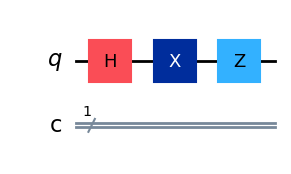

Statevector([ 0.70710678+0.j, -0.70710678+0.j],
            dims=(2,))
{'0': 494, '1': 530}


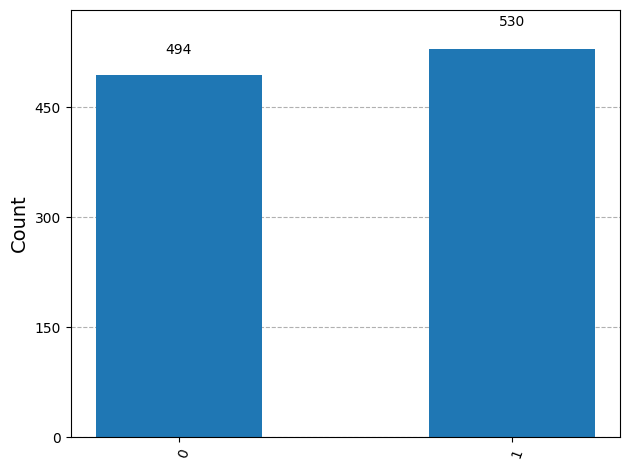

In [3]:
# circuit A : H -> X -> Z
qc_a = QuantumCircuit(1, 1)
qc_a.h(0)
print("after H:", Statevector.from_instruction(qc_a))
qc_a.x(0)
print("after X:", Statevector.from_instruction(qc_a))
qc_a.z(0)
print("after Z:", Statevector.from_instruction(qc_a))

display(qc_a.draw("mpl"))
state_a = Statevector.from_instruction(qc_a)
print(state_a)

qc_a.measure(0, 0)
counts_a = sim.run(qc_a, shots=shots).result().get_counts()
print(counts_a)
display(plot_histogram(counts_a))

after Z: Statevector([1.+0.j, 0.+0.j],
            dims=(2,))
after X: Statevector([0.+0.j, 1.+0.j],
            dims=(2,))
after H: Statevector([ 0.70710678+0.j, -0.70710678+0.j],
            dims=(2,))


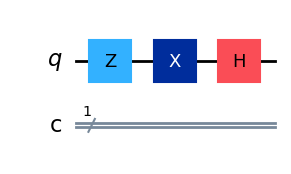

Statevector([ 0.70710678+0.j, -0.70710678+0.j],
            dims=(2,))
{'1': 494, '0': 530}


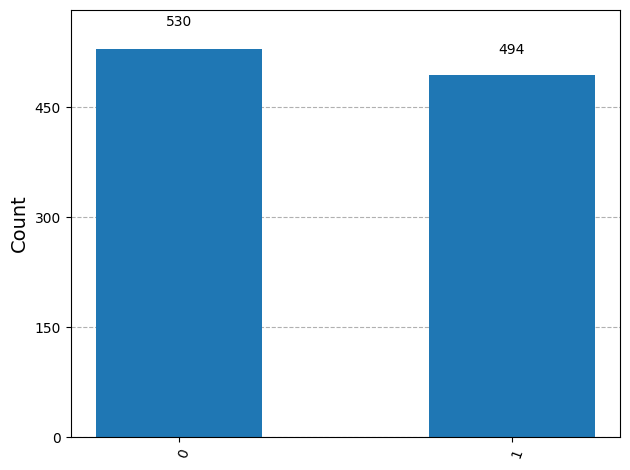

In [4]:
# circuit B : Z -> X -> H
qc_b = QuantumCircuit(1, 1)
qc_b.z(0)
print("after Z:", Statevector.from_instruction(qc_b))
qc_b.x(0)
print("after X:", Statevector.from_instruction(qc_b))
qc_b.h(0)
print("after H:", Statevector.from_instruction(qc_b))

display(qc_b.draw("mpl"))
state_b = Statevector.from_instruction(qc_b)
print(state_b)

qc_b.measure(0, 0)
counts_b = sim.run(qc_b, shots=shots).result().get_counts()
print(counts_b)
display(plot_histogram(counts_b))

True
True


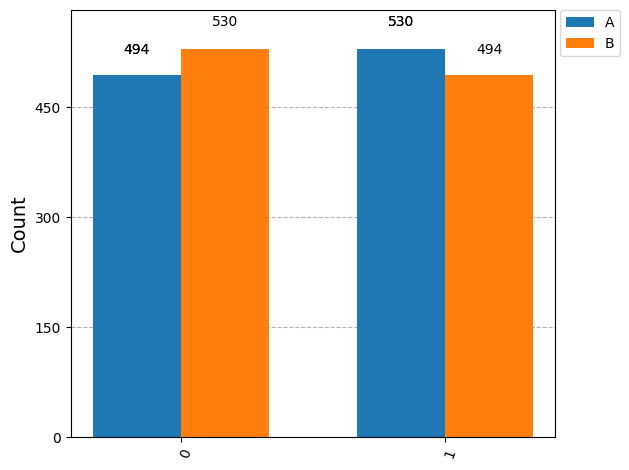

In [5]:
# both end in |->, same even with sign
print(state_a == state_b)

# reason: HZ = XH, so ZXH and HXZ are the same matrix
a = QuantumCircuit(1); a.h(0); a.x(0); a.z(0)
b = QuantumCircuit(1); b.z(0); b.x(0); b.h(0)
print(Operator(a).equiv(Operator(b)))

display(plot_histogram([counts_a, counts_b], legend=["A", "B"]))

after Y: Statevector([0.+0.j, 0.+1.j],
            dims=(2,))
after H: Statevector([0.+0.70710678j, 0.-0.70710678j],
            dims=(2,))
after X: Statevector([0.-0.70710678j, 0.+0.70710678j],
            dims=(2,))
after H: Statevector([0.+0.j, 0.-1.j],
            dims=(2,))


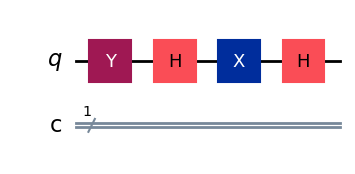

Statevector([0.+0.j, 0.-1.j],
            dims=(2,))
{'1': 1024}


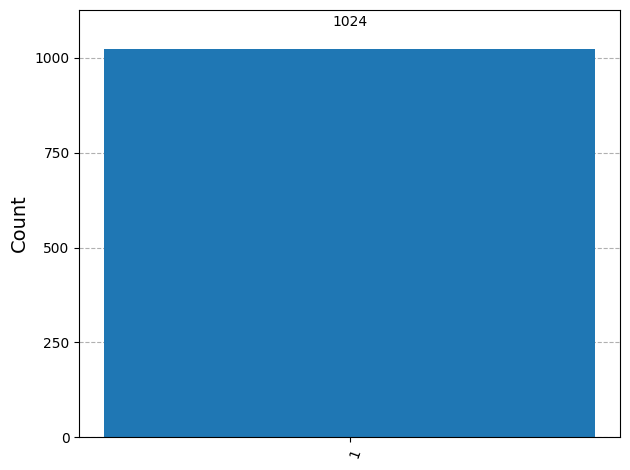

In [6]:
# my circuit : Y -> H -> X -> H  (H repeated)
# expected: |0> -> i|1> -> i|-> -> -i|-> -> -i|1>
qc = QuantumCircuit(1, 1)
qc.y(0)
print("after Y:", Statevector.from_instruction(qc))
qc.h(0)
print("after H:", Statevector.from_instruction(qc))
qc.x(0)
print("after X:", Statevector.from_instruction(qc))
qc.h(0)
print("after H:", Statevector.from_instruction(qc))

display(qc.draw("mpl"))
my_state = Statevector.from_instruction(qc)
print(my_state)

qc.measure(0, 0)
counts = sim.run(qc, shots=shots).result().get_counts()
print(counts)
display(plot_histogram(counts))
# predicted 1 every time -> matches

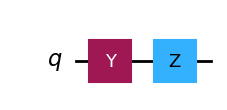

Statevector([0.+0.j, 0.-1.j],
            dims=(2,))
True


In [7]:
# challenge: H X H = Z, so Y -> Z should give the same -i|1>
qc2 = QuantumCircuit(1)
qc2.y(0)
qc2.z(0)
display(qc2.draw("mpl"))

state2 = Statevector.from_instruction(qc2)
print(state2)
print(state2 == my_state)

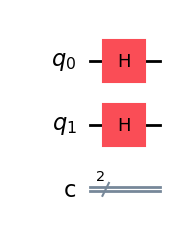

Statevector([0.5+0.j, 0.5+0.j, 0.5+0.j, 0.5+0.j],
            dims=(2, 2))
{'01': 255, '11': 272, '00': 246, '10': 251}


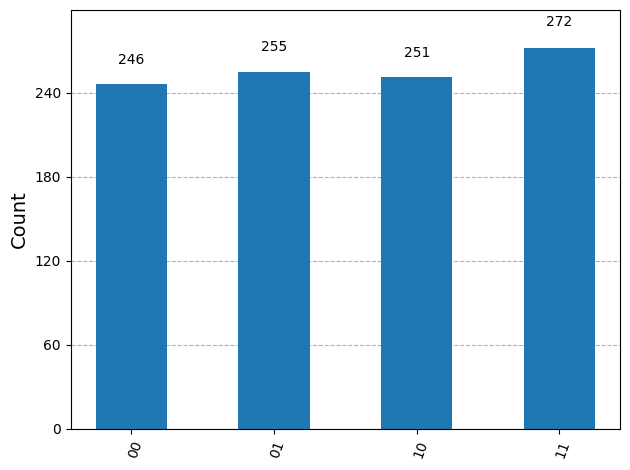

0.0


In [8]:
# two qubits, H on both
qc = QuantumCircuit(2, 2)
qc.h(0)
qc.h(1)
display(qc.draw("mpl"))

state = Statevector.from_instruction(qc)
print(state)
# (|00> + |01> + |10> + |11>)/2 = |+>|+>

qc.measure([0, 1], [0, 1])
counts = sim.run(qc, shots=shots).result().get_counts()
print(counts)
display(plot_histogram(counts))

# separable if a00*a11 - a01*a10 = 0
a = state.data
print(abs(a[0] * a[3] - a[1] * a[2]))

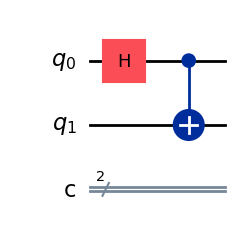

Statevector([0.70710678+0.j, 0.        +0.j, 0.        +0.j,
             0.70710678+0.j],
            dims=(2, 2))
{'00': 535, '11': 489}


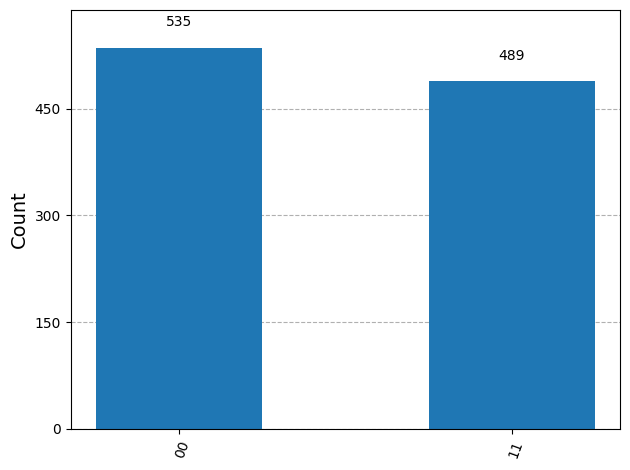

0.4999999999999999


In [9]:
# H + CNOT
qc = QuantumCircuit(2, 2)
qc.h(0)
qc.cx(0, 1)
display(qc.draw("mpl"))

state = Statevector.from_instruction(qc)
print(state)
# (|00> + |11>)/sqrt2

qc.measure([0, 1], [0, 1])
counts = sim.run(qc, shots=shots).result().get_counts()
print(counts)
display(plot_histogram(counts))

a = state.data
print(abs(a[0] * a[3] - a[1] * a[2]))
# 0.5, not 0 -> entangled. only 00 and 11

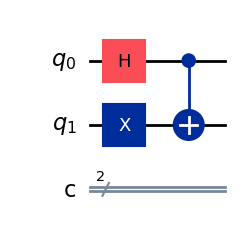

Statevector([0.        +0.j, 0.70710678+0.j, 0.70710678+0.j,
             0.        +0.j],
            dims=(2, 2))
True
{'10': 513, '01': 511}


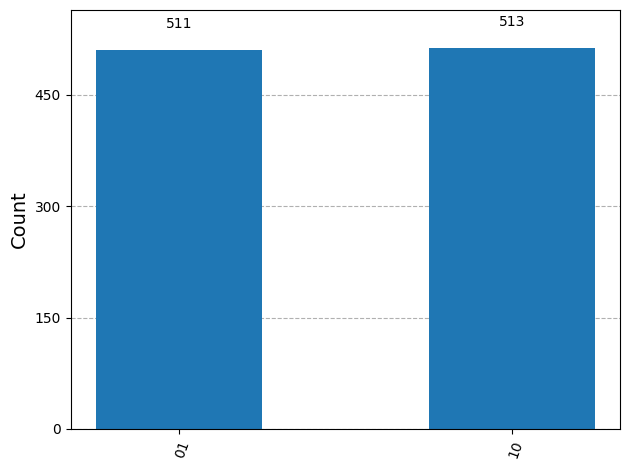

In [10]:
# psi+ = (|01> + |10>)/sqrt2
# flip q1 first so the qubits start different, then H + CNOT keeps them opposite
qc = QuantumCircuit(2, 2)
qc.x(1)
qc.h(0)
qc.cx(0, 1)
display(qc.draw("mpl"))

state = Statevector.from_instruction(qc)
print(state)
print(state == Statevector(np.array([0, 1, 1, 0]) / np.sqrt(2)))

qc.measure([0, 1], [0, 1])
counts = sim.run(qc, shots=shots).result().get_counts()
print(counts)
display(plot_histogram(counts))
# 00 and 11 have amplitude 0, so only 01 and 10

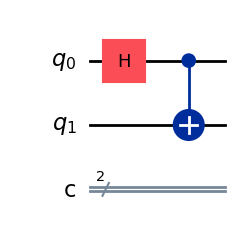

Statevector([0.70710678+0.j, 0.        +0.j, 0.        +0.j,
             0.70710678+0.j],
            dims=(2, 2))
{'00': 532, '11': 492}


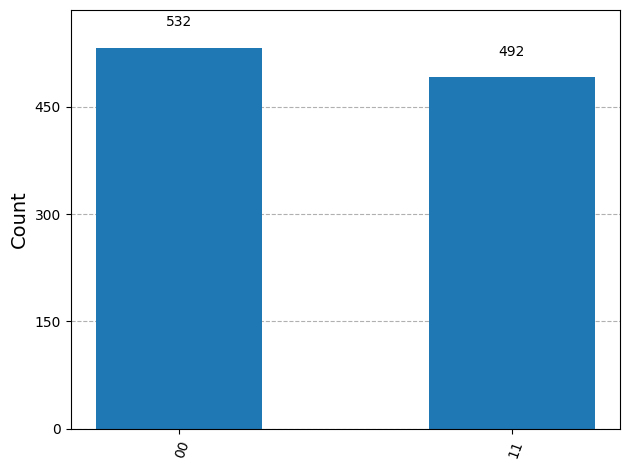

In [11]:
# phi+
qc = QuantumCircuit(2, 2)
qc.h(0)
qc.cx(0, 1)
display(qc.draw("mpl"))

state = Statevector.from_instruction(qc)
print(state)

qc.measure([0, 1], [0, 1])
counts = sim.run(qc, shots=shots).result().get_counts()
print(counts)
display(plot_histogram(counts))

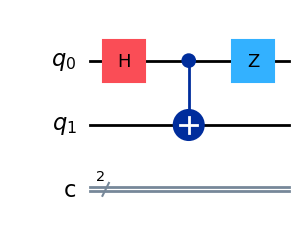

Statevector([ 0.70710678+0.j,  0.        +0.j,  0.        +0.j,
             -0.70710678+0.j],
            dims=(2, 2))
{'00': 478, '11': 546}


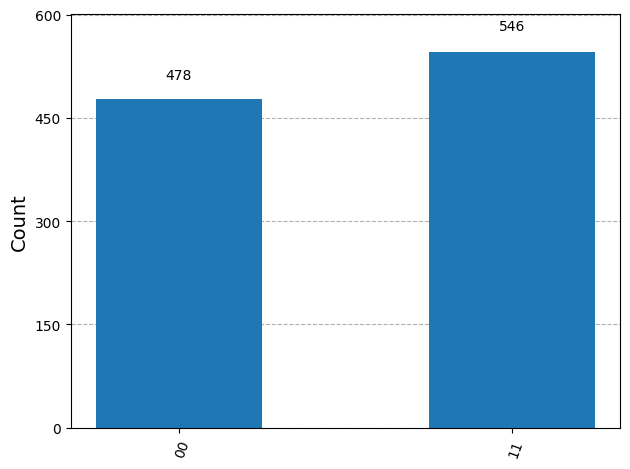

In [12]:
# phi-  (Z adds minus to |11>)
qc = QuantumCircuit(2, 2)
qc.h(0)
qc.cx(0, 1)
qc.z(0)
display(qc.draw("mpl"))

state = Statevector.from_instruction(qc)
print(state)

qc.measure([0, 1], [0, 1])
counts = sim.run(qc, shots=shots).result().get_counts()
print(counts)
display(plot_histogram(counts))

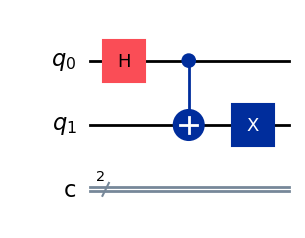

Statevector([0.        +0.j, 0.70710678+0.j, 0.70710678+0.j,
             0.        +0.j],
            dims=(2, 2))
{'01': 499, '10': 525}


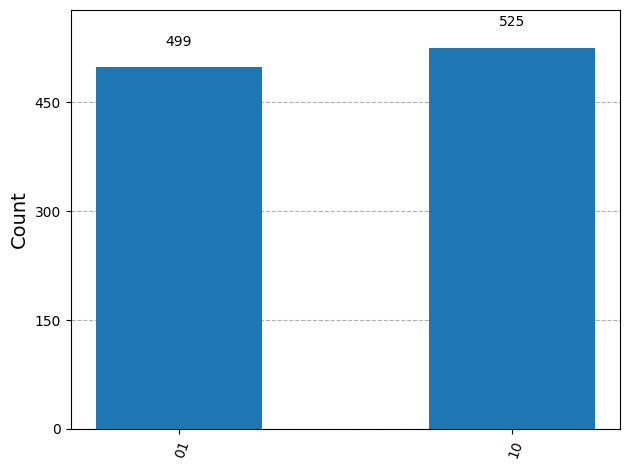

In [13]:
# psi+  (X on q1 makes 00/11 into 10/01)
qc = QuantumCircuit(2, 2)
qc.h(0)
qc.cx(0, 1)
qc.x(1)
display(qc.draw("mpl"))

state = Statevector.from_instruction(qc)
print(state)

qc.measure([0, 1], [0, 1])
counts = sim.run(qc, shots=shots).result().get_counts()
print(counts)
display(plot_histogram(counts))

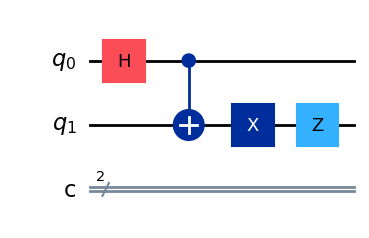

Statevector([ 0.        +0.j,  0.70710678+0.j, -0.70710678+0.j,
              0.        +0.j],
            dims=(2, 2))
{'01': 526, '10': 498}


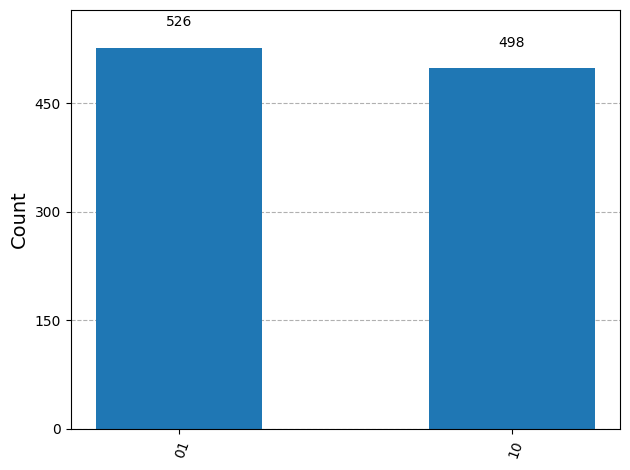

In [14]:
# psi-  (X then Z on q1, minus goes on |10>)
qc = QuantumCircuit(2, 2)
qc.h(0)
qc.cx(0, 1)
qc.x(1)
qc.z(1)
display(qc.draw("mpl"))

state = Statevector.from_instruction(qc)
print(state)

qc.measure([0, 1], [0, 1])
counts = sim.run(qc, shots=shots).result().get_counts()
print(counts)
display(plot_histogram(counts))

In [15]:
# phi+ / phi- only differ by sign, prob = amp^2 so same counts
# H on both before measuring shows the difference
for name, extra in [("phi+", None), ("phi-", "z0"), ("psi+", "x1"), ("psi-", "x1z1")]:
    qc = QuantumCircuit(2)
    qc.h(0)
    qc.cx(0, 1)
    if extra == "z0":
        qc.z(0)
    if extra in ("x1", "x1z1"):
        qc.x(1)
    if extra == "x1z1":
        qc.z(1)
    qc.h([0, 1])
    print(name, Statevector.from_instruction(qc).probabilities_dict())

phi+ {np.str_('00'): np.float64(0.4999999999999998), np.str_('01'): np.float64(5.286997409534849e-34), np.str_('10'): np.float64(5.286997409534849e-34), np.str_('11'): np.float64(0.4999999999999998)}
phi- {np.str_('00'): np.float64(5.286997409534849e-34), np.str_('01'): np.float64(0.4999999999999998), np.str_('10'): np.float64(0.4999999999999998), np.str_('11'): np.float64(5.286997409534849e-34)}
psi+ {np.str_('00'): np.float64(0.4999999999999998), np.str_('01'): np.float64(5.286997409534849e-34), np.str_('10'): np.float64(5.286997409534849e-34), np.str_('11'): np.float64(0.4999999999999998)}
psi- {np.str_('00'): np.float64(5.286997409534849e-34), np.str_('01'): np.float64(0.4999999999999998), np.str_('10'): np.float64(0.4999999999999998), np.str_('11'): np.float64(5.286997409534849e-34)}


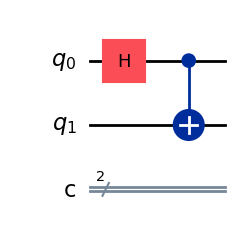

Statevector([0.70710678+0.j, 0.        +0.j, 0.        +0.j,
             0.70710678+0.j],
            dims=(2, 2))
0.4999999999999999
{'11': 509, '00': 515}


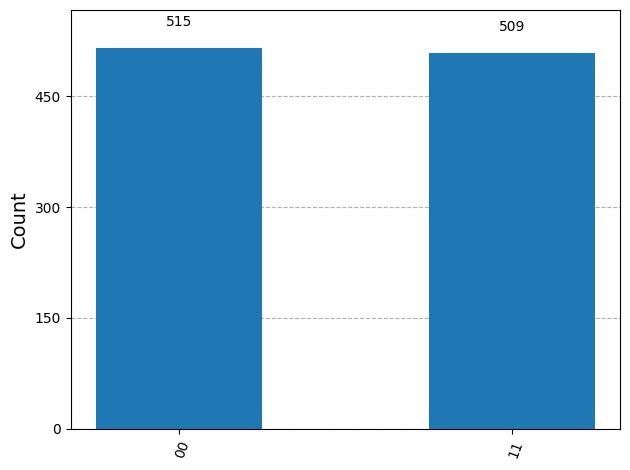

In [16]:
# detective circuit 1
qc = QuantumCircuit(2, 2)
qc.h(0)
qc.cx(0, 1)
display(qc.draw("mpl"))

state = Statevector.from_instruction(qc)
print(state)
a = state.data
print(abs(a[0] * a[3] - a[1] * a[2]))

qc.measure([0, 1], [0, 1])
counts = sim.run(qc, shots=shots).result().get_counts()
print(counts)
display(plot_histogram(counts))
# can't split (|00>+|11>) into two single qubit states -> entangled

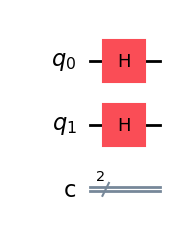

Statevector([0.5+0.j, 0.5+0.j, 0.5+0.j, 0.5+0.j],
            dims=(2, 2))
0.0
{'11': 245, '01': 272, '00': 259, '10': 248}


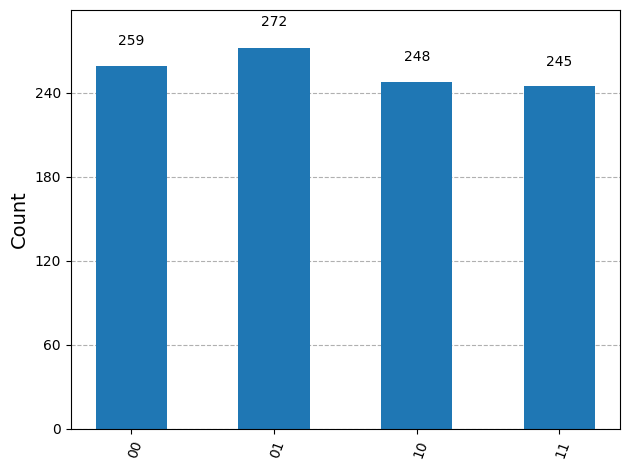

In [17]:
# detective circuit 2
qc = QuantumCircuit(2, 2)
qc.h(0)
qc.h(1)
display(qc.draw("mpl"))

state = Statevector.from_instruction(qc)
print(state)
a = state.data
print(abs(a[0] * a[3] - a[1] * a[2]))

qc.measure([0, 1], [0, 1])
counts = sim.run(qc, shots=shots).result().get_counts()
print(counts)
display(plot_histogram(counts))
# no 2 qubit gate -> separable, |+>|+>

before cx: Statevector([ 0.5+0.j, -0.5+0.j,  0.5+0.j, -0.5+0.j],
            dims=(2, 2))


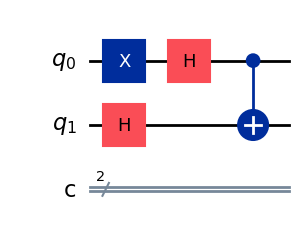

after cx:  Statevector([ 0.5+0.j, -0.5+0.j,  0.5+0.j, -0.5+0.j],
            dims=(2, 2))
0.0
{'01': 213, '10': 257, '00': 283, '11': 271}


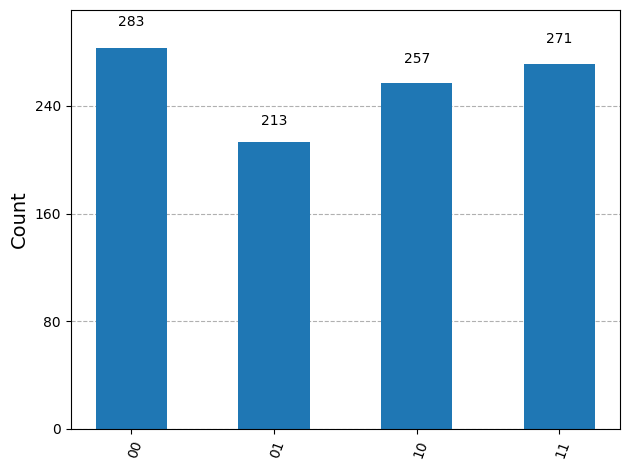

In [18]:
# detective circuit 3
qc = QuantumCircuit(2, 2)
qc.x(0)
qc.h(0)
qc.h(1)
print("before cx:", Statevector.from_instruction(qc))
qc.cx(0, 1)
display(qc.draw("mpl"))

state = Statevector.from_instruction(qc)
print("after cx: ", state)
a = state.data
print(abs(a[0] * a[3] - a[1] * a[2]))

qc.measure([0, 1], [0, 1])
counts = sim.run(qc, shots=shots).result().get_counts()
print(counts)
display(plot_histogram(counts))
# q1 is |+> and X|+> = |+>, so the CNOT changes nothing
# state stays |+>|-> -> separable even with a CNOT